In [8]:
import numpy as np
import poisson_equation
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [9]:
def plot_potential(potential_data, N):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y)

    data = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            data[i][j] = potential_data[i * N + j]
    
    fig = go.Figure()    

    fig.add_trace(go.Surface(z=data, x=X, y=Y, colorscale="YlGnBu"))

    fig.update_layout(
        title="3D График потенциала",
        width=1000,  
        height=800, 
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Potential",
        ),
    )
    fig.show()

def compute_deviation(result, U_exact_solition):
    result = np.array(result)  
    error = np.sum(np.abs(result - U_exact_solition))
    return error

# Аналитиеское решение

In [10]:
def U_analit_function(x, y):
    value = 0
    for k in range(100):
        coef = np.pi * (2 * k + 1)
        value += np.sin(coef * x) * np.sinh(coef * y) / (np.sinh(coef) * coef)
    return 4 * value

def U_list_analit(N):
    data_result = np.zeros(N * N)
    for i in range(N):
        for j in range(N):
            x = i / (N - 1)  
            y = j / (N - 1)
            data_result[i * N + j] = U_analit_function(x, y)
    return data_result


In [11]:
U_analit = U_list_analit(100)
plot_potential(U_analit, 100)

# 3D графики потенциалов

In [12]:
all_solvers = ['Solver_Jacobi', "Solver_Gauss", "Solver_over_relaxation"]
nod_number = 100
iteration = 1000
precision = 0.01
boundary_conditions = np.zeros(nod_number * 4)
source = np.zeros(nod_number ** 2)

for i in range(nod_number):
    boundary_conditions[i] = 1.0
    boundary_conditions[i + 2*nod_number] = 0.0
    boundary_conditions[i + 1*nod_number] = 0.0
    boundary_conditions[i + 3*nod_number] = 0.0


## Метод Якоби

In [13]:
result = poisson_equation.potential_result(
                        all_solvers[0], boundary_conditions, 
                        source, nod_number, 
                        iteration, precision)
plot_potential(result, nod_number)

## Метод Гаусса

In [14]:
result = poisson_equation.potential_result(
                        all_solvers[1], boundary_conditions, 
                        source, nod_number, 
                        iteration, precision)
plot_potential(result, nod_number)

## Метод сверхрелаксации

In [15]:
result = poisson_equation.potential_result(
                        all_solvers[2], boundary_conditions, 
                        source, nod_number, 
                        iteration, precision, omega = 1)
plot_potential(result, nod_number)

In [46]:
def copmare_omega(omega_min, omega_max):
    data_omega = []
    delta_omega = 0.001
    for omega in np.linspace(omega_min, omega_max, int(np.round((omega_max - omega_min)/delta_omega))):
        result = poisson_equation.potential_result(
                            all_solvers[2], boundary_conditions, 
                            source, nod_number, 
                            iteration, precision, omega)
        data_omega.append(compute_deviation(result, U_analit))

    plt.figure(figsize=(10, 6)) 

    plt.plot(np.linspace(omega_min, omega_max, int(np.round((omega_max - omega_min)/delta_omega))), np.log10(data_omega))

    plt.xlabel('Omega')
    plt.ylabel('Error')
    plt.legend() 
    plt.grid(True)
    plt.show()
        

/tmp/ipykernel_3904/1062953508.py:17: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



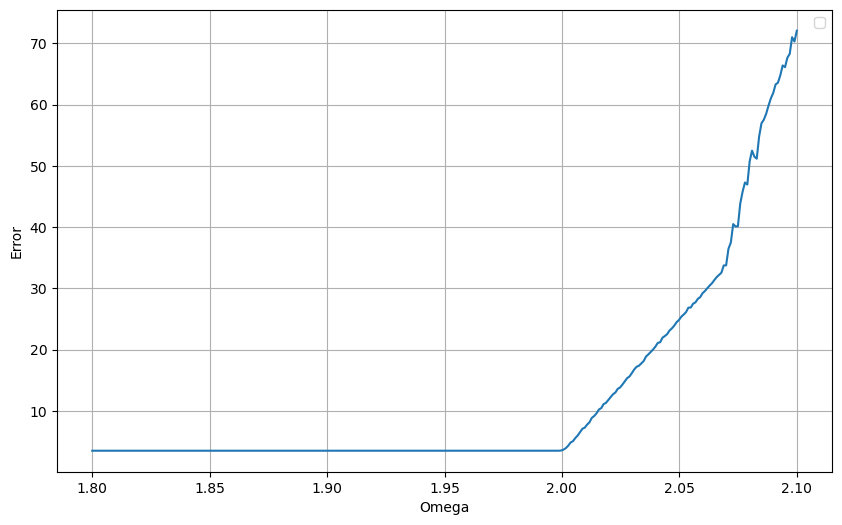

In [47]:
copmare_omega(1.8, 2.1)

# Сравнение методов

In [ ]:
def compare_metods(N_max, delta_N, U_exact_solition):

    nod_number = 100
    precision = 0.01
    boundary_conditions = np.zeros(nod_number * 4)
    source = np.zeros(nod_number ** 2)

    for i in range(nod_number):
        boundary_conditions[i] = 1.0
        boundary_conditions[i + 2*nod_number] = 0.0
        boundary_conditions[i + 1*nod_number] = 0.0
        boundary_conditions[i + 3*nod_number] = 0.0

    # Метод Якоби
    solver_name = "Solver_Jacobi"
    deviations_jacobi = []
    iterations_jacobi = []
    iteration = 0

    while iteration < N_max:
        result = poisson_equation.potential_result(
            solver_name, boundary_conditions, 
            source, nod_number, 
            iteration, precision
        )
        
        deviation = compute_deviation(result, U_exact_solition)
        deviations_jacobi.append(deviation)
        iterations_jacobi.append(iteration)
        
        iteration += delta_N

    # Метод Гаусса
    solver_name = "Solver_Gauss"
    deviations_gauss = []
    iterations_gauss = []
    iteration = 0

    while iteration < N_max:
        result = poisson_equation.potential_result(
            solver_name, boundary_conditions, 
            source, nod_number, 
            iteration, precision
        )
        
        deviation = compute_deviation(result, U_exact_solition)
        deviations_gauss.append(deviation)
        iterations_gauss.append(iteration)
        
        iteration += delta_N

    # Метод Сверхрелаксации
    solver_name = "Solver_over_relaxation"
    deviations_over_relaxation = []
    iterations_over_relaxation = []
    omega = 1
    iteration = 0

    while iteration < N_max:
        result = poisson_equation.potential_result(
            solver_name, boundary_conditions, 
            source, nod_number, 
            iteration, precision, omega
        )
        
        deviation = compute_deviation(result, U_exact_solition)
        deviations_over_relaxation.append(deviation)
        iterations_over_relaxation.append(iteration)
        
        iteration += delta_N

    plt.figure(figsize=(10, 6)) 

    plt.plot(iterations_jacobi, np.log10(deviations_jacobi), label='Jacobi')
    plt.plot(iterations_gauss, np.log10(deviations_gauss), label='Gauss')
    plt.plot(iterations_over_relaxation, np.log10(deviations_over_relaxation), label='over_relaxation')

    plt.xlabel('Number of Iterations')
    plt.title('Convergence of the Solver')
    plt.legend() 
    plt.grid(True)
    plt.show()

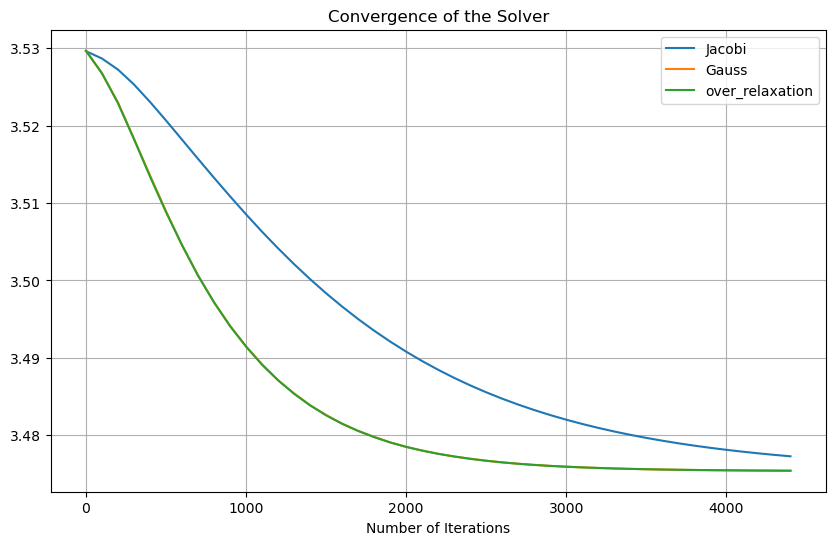

In [44]:
N_max = 4500
delta_N = 100
value = 0.5  # до какого числа считать различия (от пробных значений на 0 итерации)
compare_metods(N_max, delta_N, U_analit)

In [62]:

def convergence_vs_grid(N_values, solver_name, precision_compare):
    iterations_needed = []
    
    for N in N_values:
        nod_number = N
        precision = 0.1
        boundary_conditions = np.zeros(nod_number * 4)
        source = np.zeros(nod_number ** 2)
        
        for i in range(nod_number):
            boundary_conditions[i] = 1.0
            boundary_conditions[i + 2 * nod_number] = 0.0
            boundary_conditions[i + 1 * nod_number] = 0.0
            boundary_conditions[i + 3 * nod_number] = 0.0
        
        iteration = 10
        result = poisson_equation.potential_result(
                solver_name, boundary_conditions, source, nod_number, iteration, precision
            )
        while compute_deviation(result, U_list_analit(nod_number)) > precision_compare:
            result = poisson_equation.potential_result(
                solver_name, boundary_conditions, source, nod_number, iteration, precision
            )
            iteration += 10
        
        iterations_needed.append(iteration)
    
    plt.plot(N_values, iterations_needed, marker='o', linestyle='-', label=solver_name)
    plt.xlabel('Grid size N')
    plt.ylabel('Iterations to Convergence')
    plt.title(f'Convergence iterations vs Grid size for {solver_name}')
    plt.legend()
    plt.grid(True)
    plt.show()



In [64]:
# N_values = range(30, 50, 2) 
# precision_compare = 750
# convergence_vs_grid(N_values, "Solver_Jacobi", precision_compare)
# convergence_vs_grid(N_values, "Solver_Gauss", precision_compare)
# convergence_vs_grid(N_values, "Solver_over_relaxation", precision_compare)

# Задание 5

In [68]:
all_solvers = ['Solver_Jacobi', "Solver_Gauss", "Solver_over_relaxation"]
nod_number = 100
iteration = 1000
precision = 0.01
omega = 1.5
boundary_conditions = np.zeros(nod_number * 4)
source = np.zeros(nod_number ** 2)

for i in range(nod_number):
    boundary_conditions[i] = 1.0
    boundary_conditions[i + 2*nod_number] = -1.0
    boundary_conditions[i + 1*nod_number] = 0.0
    boundary_conditions[i + 3*nod_number] = 0.0


In [71]:
result = poisson_equation.potential_result(
                        all_solvers[2], boundary_conditions, 
                        source, nod_number, 
                        iteration, precision, omega)
plot_potential(result, nod_number)